In [ ]:
cd ../Lineage_Tree_Construction/Moslin/

/project/imoskowitz/yubin/Lineage_Tree_Construction/Moslin


We need to prepare a couple things to make this work

- Gene Expression
- Lineage Information for earlier Cx and later Cy time points
- Also need to figure out a way to combine multiple replicates per time point, since moslin does not support that 

In [16]:
import warnings
from typing import List, Literal, Optional, Tuple

import moscot as mt
import moscot.plotting as mtp
import ot
import tqdm
from moscot.problems.time import LineageProblem, TemporalProblem

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import euclidean_distances

import matplotlib.pyplot as plt

import scanpy as sc
from anndata import AnnData

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)

Import Utility Functions


In [6]:
from utility import compute_w2, get_cost, compute_errors

### TedSim Dataset

#### Loading Dataset

In [14]:
adata = mt.datasets.tedsim()
adata.obs["time"] = pd.to_numeric(adata.obs["time"]).astype("category")
adata

AnnData object with n_obs × n_vars = 8448 × 500
    obs: 'parent', 'depth', 'cellID', 'time', 'state', 'time_point'
    uns: 'cluster_colors', 'couplings', 'metadata', 'state_colors', 'tree'
    obsm: 'barcodes'
    obsp: 'cost_matrices'

In [42]:
adata.obs['time_point'].unique()

[12.0, 8.0]
Categories (2, float64): [8.0, 12.0]

#### Normalize and Preprocessing

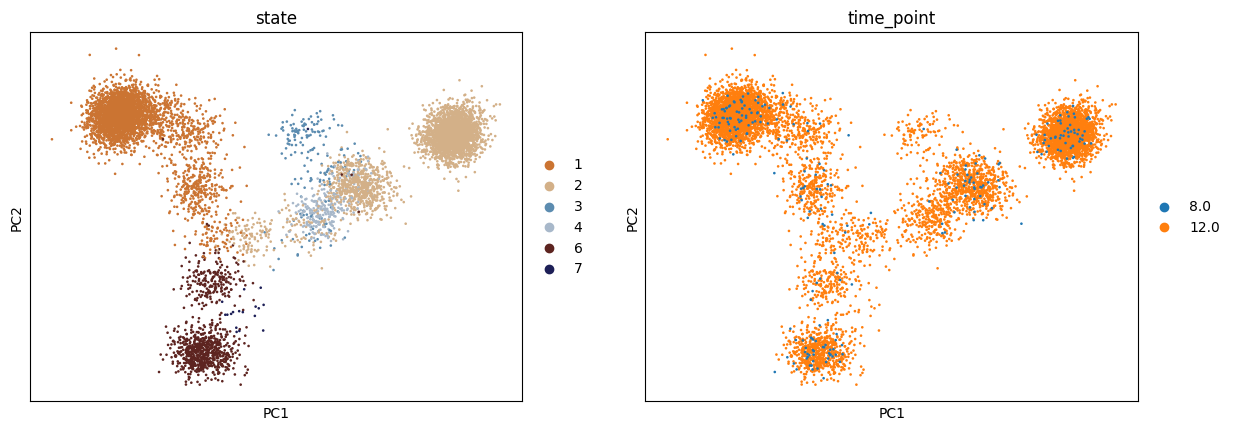

In [19]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.pca(adata, random_state=0)

sc.pl.pca(adata, color=["state", "time_point"])

#### Preparing Lineage Problem

In [20]:
lp = LineageProblem(adata)
lp = lp.prepare(
    time_key="time",
    joint_attr="X_pca",
    lineage_attr={"attr": "obsp", "key": "cost_matrices", "cost": "custom"},
)

#### Solving the Lineage Problem

In [21]:
lp = lp.solve(alpha=0.99, epsilon=1e-3, tau_a=0.99)

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(256, 8192)].                                   


### Analyzing Celltype transition

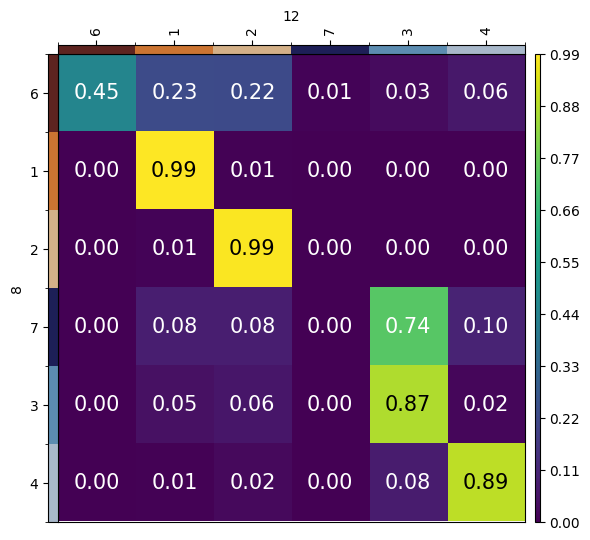

In [22]:
order = ["6", "1", "2", "7", "3", "4"]

cell_transition = lp.cell_transition(
    source=8,
    target=12,
    source_groups={"state": order},
    target_groups={"state": order},
    forward=True,
    key_added="lp_transitions",
)

mtp.cell_transition(lp, fontsize=15, figsize=(5, 5), key="lp_transitions")

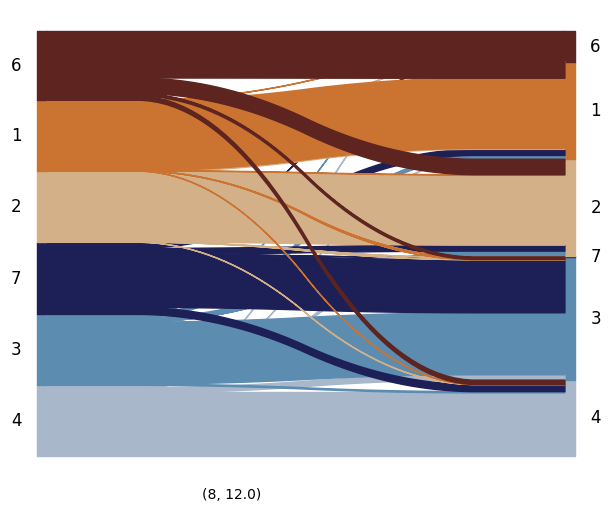

In [23]:
lp.sankey(
    source=8,
    target=12,
    source_groups={"state": order[::-1]},
    target_groups={"state": order[::-1]},
)
mtp.sankey(lp, figsize=(6, 5))

In [24]:
coupling_gt = adata.uns["couplings"]["true"].astype(float)

In [25]:
tp = TemporalProblem(adata)
tp = tp.prepare(time_key="time", joint_attr="X_pca")
tp = tp.solve(epsilon=1e-3, tau_a=0.99)

# compute the aggregated transition matrix
cell_transition = tp.cell_transition(
    source=8,
    target=12,
    source_groups={"state": order},
    target_groups={"state": order},
    forward=True,
    key_added="tp_transitions",
)

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(256, 8192)].                                   


In [26]:
# instantiate a dummy problem for this
gt = TemporalProblem(adata).prepare(time_key="time", joint_attr="X_pca")

# pass the ground-truth solution
gt[8, 12].set_solution(coupling_gt)

# compute the aggregated transition matrix
cell_transition = gt.cell_transition(
    source=8,
    target=12,
    source_groups={"state": order},
    target_groups={"state": order},
    forward=True,
    key_added="gt_transitions",
)

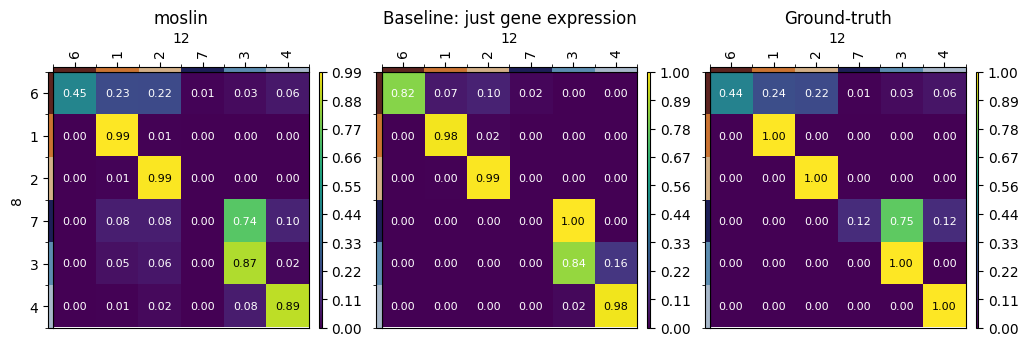

In [27]:
# Create a 1x3 grid of subplots
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))

# moslin
axes[0] = mtp.cell_transition(
    lp,
    fontsize=8,
    figsize=(5, 5),
    return_fig=True,
    ax=axes[0],
    key="lp_transitions",
)

# baseline OT
axes[1] = mtp.cell_transition(
    tp,
    fontsize=8,
    figsize=(5, 5),
    return_fig=True,
    ax=axes[1],
    key="tp_transitions",
)

# ground-truth
axes[2] = mtp.cell_transition(
    gt,
    fontsize=8,
    figsize=(5, 5),
    return_fig=True,
    ax=axes[2],
    key="gt_transitions",
)

fig.subplots_adjust(wspace=0.2)

# add some titles
axes[2].axes[4].set_title("moslin")
axes[2].axes[7].set_title("Baseline: just gene expression")
axes[2].axes[10].set_title("Ground-truth")

# remove some repeated y-labels and ticks
axes[2].axes[8].set_ylabel("")
axes[2].axes[8].set_yticks([])
axes[2].axes[11].set_ylabel("")
axes[2].axes[11].set_yticks([])

plt.show()

In [28]:
# retrieve the coupling matrices
coupling_moslin = np.asarray(lp.solutions[8, 12].transport_matrix, dtype=float)
coupling_ot = np.asarray(tp.solutions[8, 12].transport_matrix, dtype=float)
coupling_outer = np.asarray(adata.uns["couplings"]["independent"], dtype=float)

# compute errors for moslin
anc_moslin, desc_moslin = compute_errors(adata, p_1=coupling_moslin, p_2=coupling_gt)

# compute errors for the OT approach
anc_ot, desc_ot = compute_errors(adata, p_1=coupling_ot, p_2=coupling_gt)

# compute errors for an uninformative coupling as baseline
anc_outer, desc_outer = compute_errors(adata, p_1=coupling_outer, p_2=coupling_gt)

100%|██████████████████████████████████████████████████████████████████████████████████| 256/256 [04:17<00:00,  1.00s/it]


In [29]:
mean_error_moslin = (
    np.mean(anc_moslin) / np.mean(anc_outer)
    + np.mean(desc_moslin) / np.mean(desc_outer)
) / 2
mean_error_ot = (
    np.mean(anc_ot) / np.mean(anc_outer) + np.mean(desc_ot) / np.mean(desc_outer)
) / 2

print(
    f"Mean error moslin = {mean_error_moslin:.2f}, mean error OT = {mean_error_ot:.2f}."
)

Mean error moslin = 0.32, mean error OT = 0.60.


#### Zooming in one sub population

In [30]:
common_kwargs = {
    "source": 8,
    "target": 12,
    "data": "state",
    "subset": "6",
}

# compute the descendant distribution for either approach
lp_push = lp.push(key_added="lp_transitions", **common_kwargs)
tp_push = tp.push(key_added="tp_transitions", **common_kwargs)
gt_push = gt.push(key_added="gt_transitions", **common_kwargs)


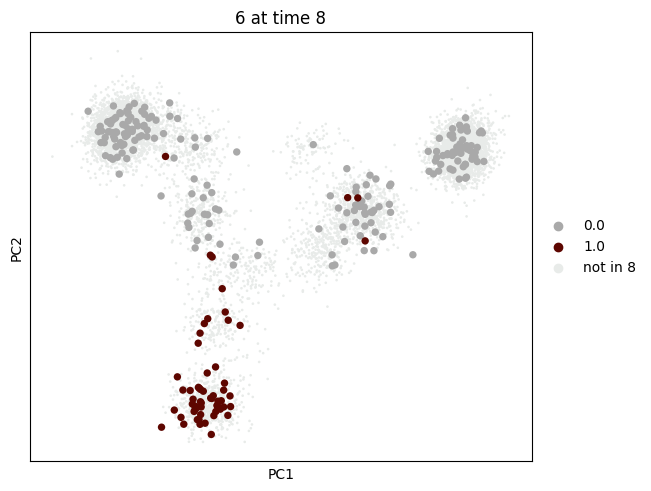

In [34]:
mtp.push(
    lp,
    time_points=[8],
    key="lp_transitions",
    basis="pca",
    dot_scale_factor=8,
)

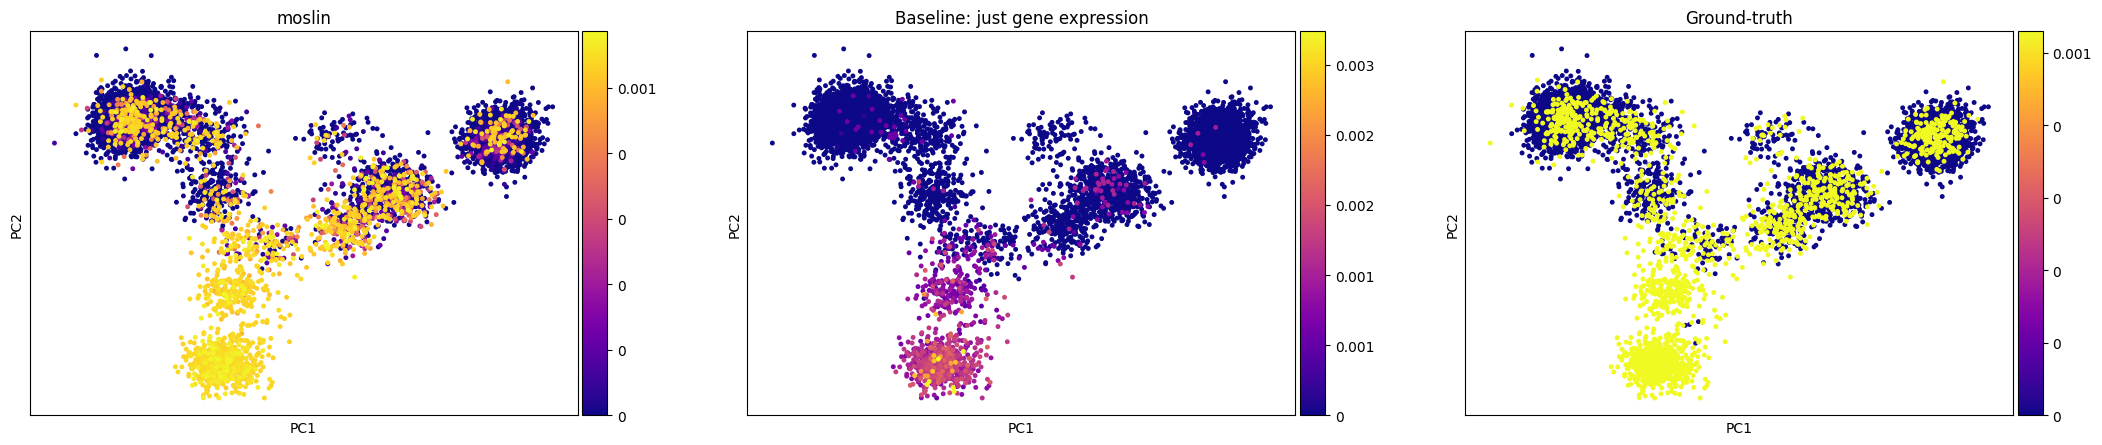

In [35]:
mask = adata.obs["time_point"] == 12.0

sc.pl.scatter(
    adata[mask],
    basis="pca",
    color=["lp_transitions", "tp_transitions", "gt_transitions"],
    size=50,
    color_map="plasma",
    title=["moslin", "Baseline: just gene expression", "Ground-truth"],
)